## Analysis 1 - Career Slugging Percentage by Birth Country
### Which country produces players with the greatest average hitting power?

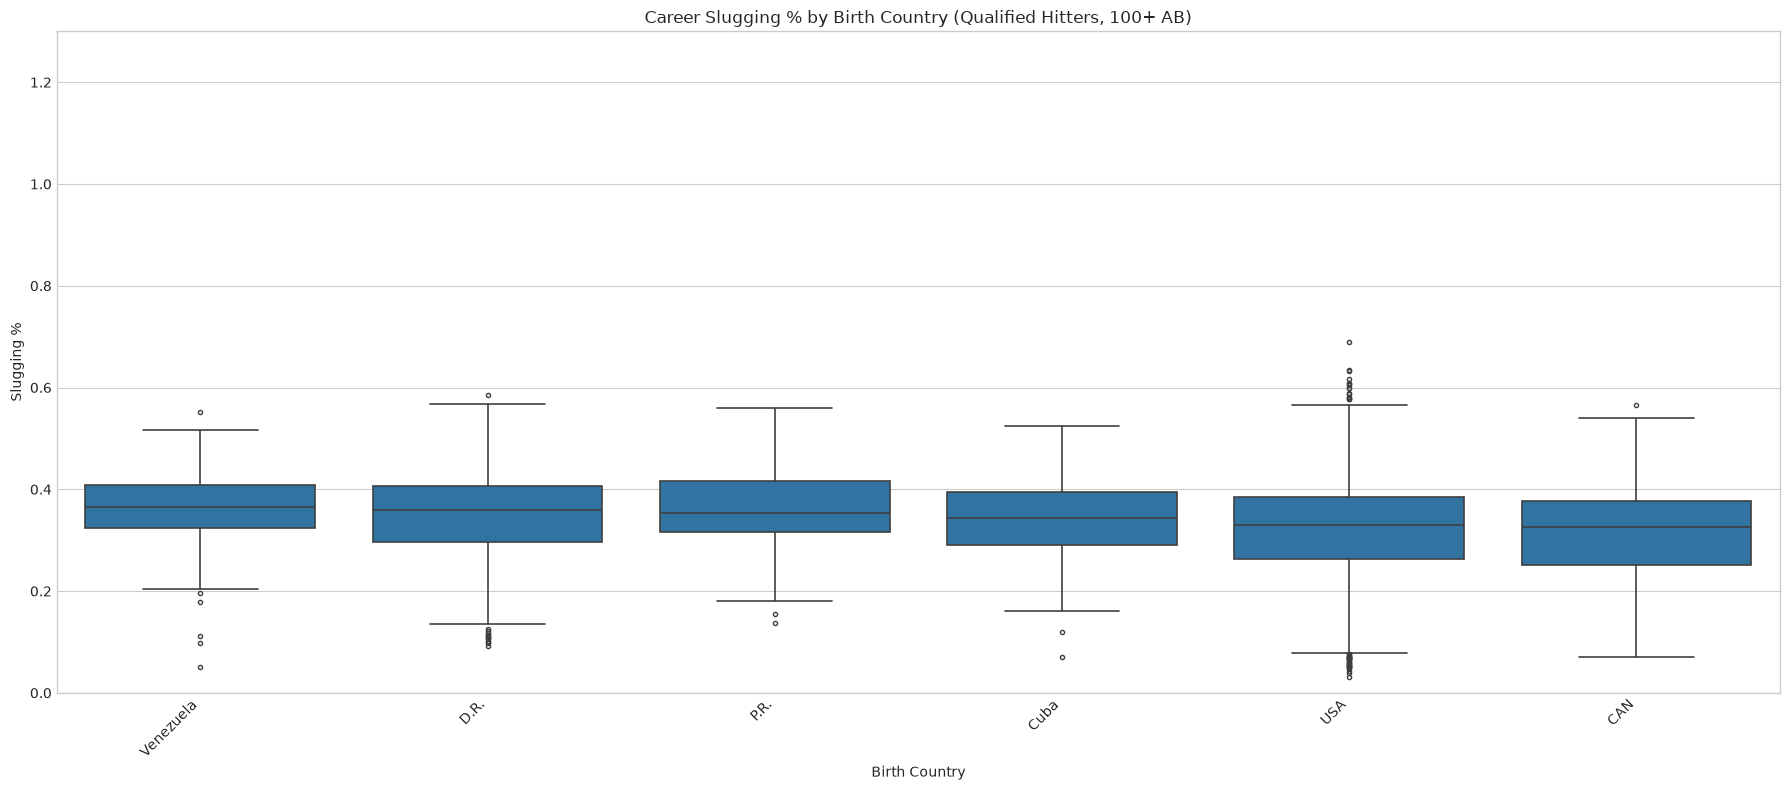


Analysis 1 summary:
              count      mean    median
birthCountry                           
USA            7759  0.320682  0.329516
D.R.            280  0.343502  0.358467
Venezuela       169  0.358665  0.364243
P.R.            161  0.361050  0.352831
Cuba            107  0.338065  0.344413
CAN             103  0.314174  0.325000


In [10]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

plt.style.use("seaborn-v0_8-whitegrid")

# Load required datasets
batting = pd.read_csv(Path("core") / "Batting.csv")
people = pd.read_csv(Path("core") / "People.csv")

# Normalize numeric columns
for df, cols in [
    (batting, ["AB", "H", "2B", "3B", "HR"]),
]:
    for col in cols:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")

# -----------------------------------------------------------------------------
# Analysis 1: Slugging % vs Birth Country
# -----------------------------------------------------------------------------
# Build career totals for each player using all seasons
batting_career = batting[["playerID", "AB", "H", "2B", "3B", "HR"]].copy()
for col in ["AB", "H", "2B", "3B", "HR"]:
    batting_career[col] = batting_career[col].fillna(0)

career_stats = (
    batting_career.groupby("playerID", as_index=False)
    .sum(numeric_only=True)
    .merge(people[["playerID", "birthCountry"]], on="playerID", how="left")
)

career_stats["singles"] = career_stats["H"] - career_stats["2B"] - career_stats["3B"] - career_stats["HR"]
career_stats["slugging_pct"] = (
    career_stats["singles"] + 2 * career_stats["2B"] + 3 * career_stats["3B"] + 4 * career_stats["HR"]
) / career_stats["AB"]

# Restrict to qualified hitters with 100+ AB and valid birth countries
qualified_players = career_stats[
    (career_stats["AB"] >= 100)
    & (career_stats["birthCountry"].notna())
    & (career_stats["birthCountry"] != "")
].copy()

country_counts = qualified_players["birthCountry"].value_counts()
eligible_countries = country_counts[country_counts >= 50].index
qualified_players = qualified_players[qualified_players["birthCountry"].isin(eligible_countries)].copy()

country_order = (
    qualified_players.groupby("birthCountry")["slugging_pct"]
    .median()
    .sort_values(ascending=False)
    .index
)

fig, ax = plt.subplots(figsize=(18, 8))
sns.boxplot(
    data=qualified_players,
    x="birthCountry",
    y="slugging_pct",
    order=country_order,
    linewidth=1.2,
    flierprops={"marker": "o", "markersize": 3},
    ax=ax,
)
ax.set_title("Career Slugging % by Birth Country (Qualified Hitters, 100+ AB)")
ax.set_xlabel("Birth Country")
ax.set_ylabel("Slugging %")
ax.set_ylim(0, 1.3)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# Summary of countries with 50+ qualified hitters
country_summary = (
    qualified_players.groupby("birthCountry")["slugging_pct"]
    .agg(["count", "mean", "median"])
    .sort_values(["count", "median"], ascending=[False, False])
)
print("\nAnalysis 1 summary:")
print(country_summary.to_string())

## Analysis 2 - Career Slugging Percentage vs Career Batting Average

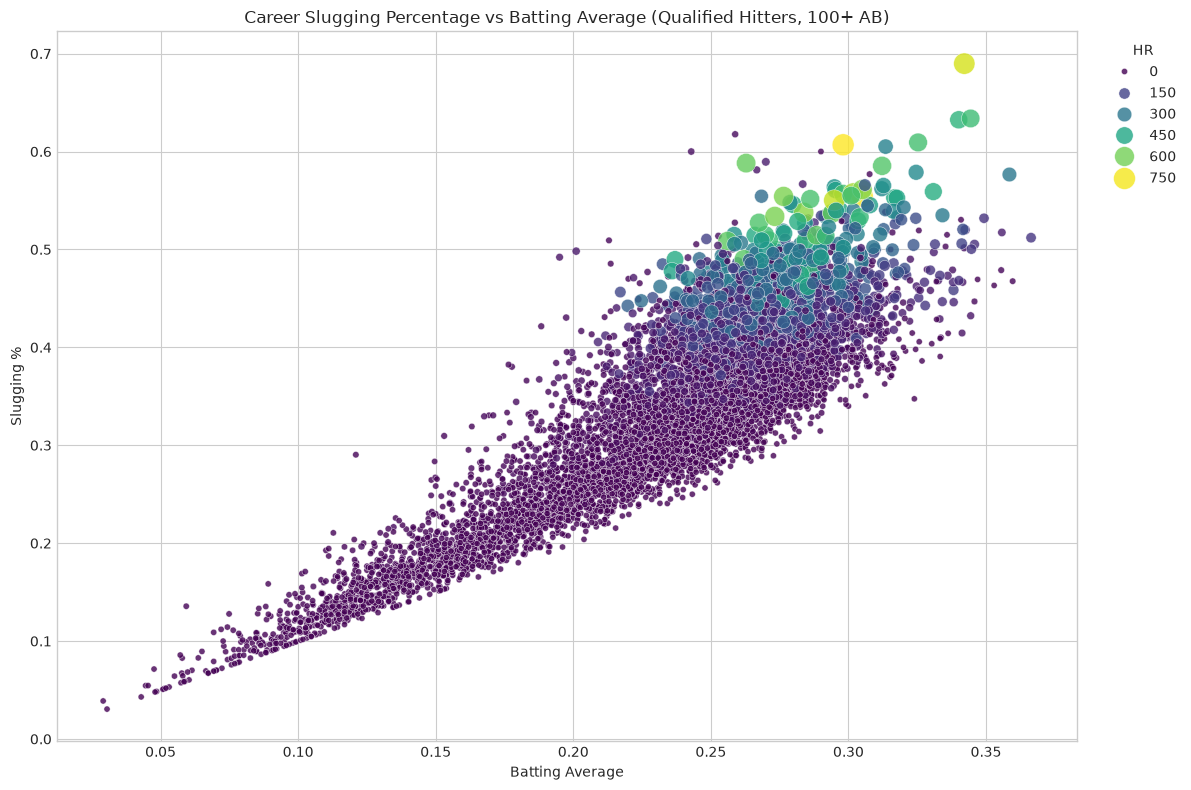


Analysis 2 sample of top 10 players by slugging:
 playerID   AB    H  HR  batting_avg  slugging_pct
 ruthba01 8398 2873 714     0.342105      0.689807
willite01 7706 2654 521     0.344407      0.633792
gehrilo01 8001 2721 493     0.340082      0.632421
hoskirh01  170   44  18     0.258824      0.617647
 foxxji01 8134 2646 534     0.325301      0.609294
bondsba01 9847 2935 762     0.298060      0.606885
greenha01 5193 1628 331     0.313499      0.605045
olsonma02  210   51  24     0.242857      0.600000
 bassjo01  100   29   3     0.290000      0.600000
judgeaa01  626  169  56     0.269968      0.589457


In [11]:

# -----------------------------------------------------------------------------
# Analysis 2: Career batting average vs slugging percentage
# -----------------------------------------------------------------------------
qualified_players["batting_avg"] = qualified_players["H"] / qualified_players["AB"]

fig, ax = plt.subplots(figsize=(12, 8))
sns.scatterplot(
    data=qualified_players,
    x="batting_avg",
    y="slugging_pct",
    hue="HR",
    size="HR",
    sizes=(20, 250),
    palette="viridis",
    alpha=0.8,
    ax=ax,
)
ax.set_title("Career Slugging Percentage vs Batting Average (Qualified Hitters, 100+ AB)")
ax.set_xlabel("Batting Average")
ax.set_ylabel("Slugging %")
ax.legend(title="HR", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

print("\nAnalysis 2 sample of top 10 players by slugging:")
print(
    qualified_players[["playerID", "AB", "H", "HR", "batting_avg", "slugging_pct"]]
    .sort_values("slugging_pct", ascending=False)
    .head(10)
    .to_string(index=False)
)
